In [1]:
!pip install torch torchvision matplotlib tqdm -q

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [21]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [22]:
# Diffusion parameters
NUM_TIMESTEPS = 1000
BETA_START = 0.0001
BETA_END = 0.02

# Training parameters
BATCH_SIZE = 128
EPOCHS = 80
LEARNING_RATE = 2e-4
IMAGE_SIZE = 28 # Corrected from 28 * 28


In [23]:
# Noise schedule
def create_noise_schedule(timesteps, beta_start, beta_end):
    """
    Create a linear schedule for noise variance (beta).
    Beta controls how much noise we add at each timestep.
    """
    # Linear schedule from beta_start to beta_end
    betas = torch.linspace(beta_start, beta_end, timesteps)

    # Alpha is 1 - beta (the amount of signal we keep)
    alphas = 1.0 - betas

    # Alpha_bar is the cumulative product (total signal remaining)
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    # Alpha_bar for previous timestep (needed for sampling)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

    return {
        'betas': betas,
        'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': torch.sqrt(alphas_cumprod),
        'sqrt_one_minus_alphas_cumprod': torch.sqrt(1.0 - alphas_cumprod),
    }

# Create noise schedule and move to device
noise_schedule = create_noise_schedule(NUM_TIMESTEPS, BETA_START, BETA_END)

# IMPORTANT: Move all tensors in noise_schedule to the correct device
for key in noise_schedule:
    noise_schedule[key] = noise_schedule[key].to(device)

In [24]:
# FORWARD DIFFUSION (ADD NOISE)

def forward_diffusion(x0, t, noise_schedule):
    """
    Add noise to images according to the schedule.

    x0: clean images [batch_size, channels, height, width]
    t: timesteps [batch_size] - which noise level to use

    Returns: noisy images and the noise that was added
    """
    # Sample random Gaussian noise
    noise = torch.randn_like(x0)

    # Get the noise level for each timestep
    sqrt_alpha_bar = noise_schedule['sqrt_alphas_cumprod'][t]
    sqrt_one_minus_alpha_bar = noise_schedule['sqrt_one_minus_alphas_cumprod'][t]

    # Reshape for broadcasting: [batch_size, 1, 1, 1]
    sqrt_alpha_bar = sqrt_alpha_bar.view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar = sqrt_one_minus_alpha_bar.view(-1, 1, 1, 1)

    # Apply noise: x_t = sqrt(alpha_bar) * x0 + sqrt(1 - alpha_bar) * noise
    noisy_image = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise

    return noisy_image, noise

In [25]:
# U-NET MODEL

class SimpleUNet(nn.Module):
    """
    Simplified U-Net for predicting noise.
    Takes noisy image and timestep, outputs predicted noise.
    Fixed to handle MNIST's 28x28 size properly.
    """
    def __init__(self, in_channels=1, time_dim=256):
        super().__init__()

        # Timestep embedding (converts timestep number to a feature vector)
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # Encoder (downsampling path)
        self.conv1 = nn.Conv2d(in_channels, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)

        # Timestep projection layers
        self.time_proj1 = nn.Linear(time_dim, 64)
        self.time_proj2 = nn.Linear(time_dim, 128)
        self.time_proj3 = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)

        # Decoder (upsampling path) - use regular upsampling instead of transpose conv
        self.conv_up3 = nn.Conv2d(256 + 256, 128, 3, padding=1)  # 512 because of skip connection
        self.conv_up2 = nn.Conv2d(128 + 128, 64, 3, padding=1)   # 256 because of skip connection
        self.conv_up1 = nn.Conv2d(64 + 64, 64, 3, padding=1)     # 128 because of skip connection

        # Output layer (predicts noise)
        self.output = nn.Conv2d(64, in_channels, 1)

    def forward(self, x, t):
        # Embed timestep
        t = t.float().unsqueeze(1)  # [batch_size, 1]
        #t_emb = self.time_mlp(t)     # [batch_size, time_dim]
        t_emb = sinusoidal_embedding(t, 256)

        # Encoder with timestep conditioning
        x1 = F.silu(self.conv1(x) + self.time_proj1(t_emb)[:, :, None, None])
        x1_pool = F.max_pool2d(x1, 2)  # 28 -> 14

        x2 = F.silu(self.conv2(x1_pool) + self.time_proj2(t_emb)[:, :, None, None])
        x2_pool = F.max_pool2d(x2, 2)  # 14 -> 7

        x3 = F.silu(self.conv3(x2_pool) + self.time_proj3(t_emb)[:, :, None, None])
        x3_pool = F.max_pool2d(x3, 2)  # 7 -> 3

        # Bottleneck
        b = F.silu(self.bottleneck(x3_pool))  # 3x3

        # Decoder with skip connections - use interpolation for upsampling
        up3 = F.interpolate(b, size=x3.shape[2:], mode='nearest')  # 3 -> 7
        up3 = torch.cat([up3, x3], dim=1)  # Skip connection
        up3 = F.silu(self.conv_up3(up3))

        up2 = F.interpolate(up3, size=x2.shape[2:], mode='nearest')  # 7 -> 14
        up2 = torch.cat([up2, x2], dim=1)  # Skip connection
        up2 = F.silu(self.conv_up2(up2))

        up1 = F.interpolate(up2, size=x1.shape[2:], mode='nearest')  # 14 -> 28
        up1 = torch.cat([up1, x1], dim=1)  # Skip connection
        up1 = F.silu(self.conv_up1(up1))

        # Output predicted noise
        return self.output(up1)

In [26]:
# DATA LOADING
# Transform: convert to tensor and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Maps [0,1] to [-1,1]
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Dataset loaded: {len(train_dataset)} training images")

Dataset loaded: 60000 training images


In [29]:
# TRAINING

# Initialize model
model = SimpleUNet(in_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Training loop
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, _ in progress_bar:
        images = images.to(device)

        # Sample random timesteps for each image in the batch
        t = torch.randint(0, NUM_TIMESTEPS, (images.shape[0],), device=device)

        # Add noise to images (forward diffusion)
        noisy_images, noise = forward_diffusion(images, t, noise_schedule)

        # Predict the noise using the model
        predicted_noise = model(noisy_images, t)

        # Calculate loss (MSE between actual noise and predicted noise)
        loss = F.mse_loss(predicted_noise, noise)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.6f}")

print("Training complete!")

Model parameters: 1,952,513


Epoch 1/80: 100%|██████████| 468/468 [00:25<00:00, 18.41it/s, loss=0.0521]


Epoch 1 - Average Loss: 0.133755


Epoch 2/80: 100%|██████████| 468/468 [00:25<00:00, 18.20it/s, loss=0.0455]


Epoch 2 - Average Loss: 0.057687


...

Epoch 78 - Average Loss: 0.023829


Epoch 79/80: 100%|██████████| 468/468 [00:25<00:00, 18.28it/s, loss=0.0274]


Epoch 79 - Average Loss: 0.024985


Epoch 80/80: 100%|██████████| 468/468 [00:25<00:00, 18.03it/s, loss=0.0294]

Epoch 80 - Average Loss: 0.024063
Training complete!


In [30]:
#### c
@torch.no_grad()
def sample_images(model, noise_schedule, num_images=16):
    model.eval()
    x = torch.randn(num_images, 1, 28, 28).to(device)

    for t in reversed(range(NUM_TIMESTEPS)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        eps_theta = model(x, t_batch)

        alpha_t = noise_schedule['alphas'][t]
        alpha_bar_t = noise_schedule['alphas_cumprod'][t]
        alpha_bar_prev = noise_schedule['alphas_cumprod_prev'][t]
        beta_t = noise_schedule['betas'][t]

        # Mean
        mean = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * eps_theta
        )

        if t > 0:
            var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(var) * noise
        else:
            x = mean

    return x


In [34]:
def sinusoidal_embedding(timesteps, dim):
    device = timesteps.device
    half = dim // 2
    emb = torch.exp(
        torch.arange(half, device=device) * -(np.log(10000) / (half - 1))
    )
    # Corrected line: removed extra dimensions during multiplication
    emb = timesteps * emb # Changed from timesteps[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb

In [35]:
# generate images
generated_images = sample_images(
    model,
    noise_schedule,
    num_images=16
)

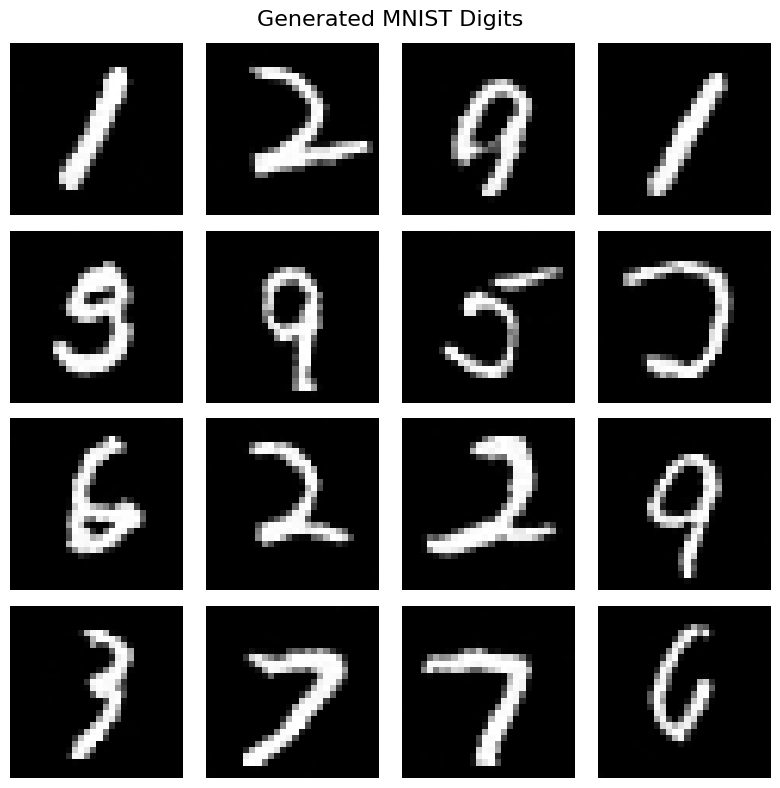

Done! Images generated successfully.


In [36]:
# VISUALIZATION

# Convert from [-1, 1] to [0, 1] for display
generated_images = (generated_images + 1) / 2
generated_images = generated_images.cpu().clamp(0, 1)

# Plot generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Generated MNIST Digits', fontsize=16)
plt.tight_layout()
plt.show()

print("Done! Images generated successfully.")